## 📦 Import Libraries

In [1]:
print("📦 Importing libraries...")
print("⏰ TensorFlow import might take 10-30 seconds on first run")
print("   Running in CPU mode (Metal GPU had compatibility issues)\n")

# Data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow & Keras (CPU mode - stable!)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Scikit-learn
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Utilities
import pickle
import json
import os
import warnings
import platform
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# System Info
print("🍎 System Info")
print(f"OS        : {platform.system()}")
print(f"Machine   : {platform.machine()}")
print(f"Python    : {platform.python_version()}")

# TensorFlow Info
print(f"\n✅ All libraries imported successfully!")
print(f"📌 TensorFlow version: {tf.__version__}")
print(f"💻 Mode: CPU (tensorflow-metal disabled due to compatibility)")

devices = tf.config.list_physical_devices()
print("🔧 Available devices:")
for d in devices:
    print(f"   - {d.device_type}: {d.name}")
    
print("\n💡 TIP: Training akan lebih lambat di CPU, tapi lebih stabil!")
print("⏰ Estimasi training time: ~20-40 menit untuk LSTM")

📦 Importing libraries...
⏰ TensorFlow import might take 10-30 seconds on first run
   Running in CPU mode (Metal GPU had compatibility issues)

🍎 System Info
OS        : Darwin
Machine   : arm64
Python    : 3.11.14

✅ All libraries imported successfully!
📌 TensorFlow version: 2.13.0
💻 Mode: CPU (tensorflow-metal disabled due to compatibility)
🔧 Available devices:
   - CPU: /physical_device:CPU:0

💡 TIP: Training akan lebih lambat di CPU, tapi lebih stabil!
⏰ Estimasi training time: ~20-40 menit untuk LSTM


## 📁 Load Preprocessed Data

In [2]:
# Load data
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print("📊 Data Loaded:")
print(f"   Training:   {len(train_df):,} samples")
print(f"   Validation: {len(val_df):,} samples")
print(f"   Test:       {len(test_df):,} samples")

📊 Data Loaded:
   Training:   36,861 samples
   Validation: 7,899 samples
   Test:       7,899 samples


In [3]:
# Load label encoder
with open('../models/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Load metadata
with open('../data/processed/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

num_classes = metadata['num_classes']

print(f"\n🏷️ Label Info:")
print(f"   Number of classes: {num_classes}")
print(f"   Classes: {metadata['classes']}")


🏷️ Label Info:
   Number of classes: 7
   Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


In [4]:
# Prepare data untuk LSTM (gunakan processed_text - tanpa stopwords)
X_train = train_df['processed_text'].fillna('').astype(str).values
X_val = val_df['processed_text'].fillna('').astype(str).values
X_test = test_df['processed_text'].fillna('').astype(str).values

y_train = train_df['label_encoded'].values
y_val = val_df['label_encoded'].values
y_test = test_df['label_encoded'].values

print("✅ Data prepared for LSTM training")
print(f"   Train samples with empty text: {sum(len(x.strip()) == 0 for x in X_train)}")
print(f"   Val samples with empty text: {sum(len(x.strip()) == 0 for x in X_val)}")
print(f"   Test samples with empty text: {sum(len(x.strip()) == 0 for x in X_test)}")

✅ Data prepared for LSTM training
   Train samples with empty text: 108
   Val samples with empty text: 26
   Test samples with empty text: 23


## 🔤 Tokenization dan Padding

In [5]:
# Hyperparameters - DITINGKATKAN untuk accuracy lebih baik
MAX_WORDS = 20000  # Vocabulary size - DITINGKATKAN dari 10000
MAX_LEN = 128      # Sequence length - DITINGKATKAN dari 100 (sama dengan BERT)
EMBEDDING_DIM = 256  # DITINGKATKAN dari 128

print(f"⚙️ Hyperparameters (UPGRADED):")
print(f"   MAX_WORDS (vocab size): {MAX_WORDS:,} ⬆️ (from 10,000)")
print(f"   MAX_LEN (sequence length): {MAX_LEN} ⬆️ (from 100)")
print(f"   EMBEDDING_DIM: {EMBEDDING_DIM} ⬆️ (from 128)")
print(f"\n💡 Changes will improve model capacity and accuracy!")

⚙️ Hyperparameters (UPGRADED):
   MAX_WORDS (vocab size): 20,000 ⬆️ (from 10,000)
   MAX_LEN (sequence length): 128 ⬆️ (from 100)
   EMBEDDING_DIM: 256 ⬆️ (from 128)

💡 Changes will improve model capacity and accuracy!


In [6]:
# Tokenize text
print("\n🔤 Tokenizing text...")
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print(f"✅ Tokenization complete!")
print(f"   Vocabulary size: {len(tokenizer.word_index):,}")


🔤 Tokenizing text...
✅ Tokenization complete!
   Vocabulary size: 59,446


In [7]:
# Padding sequences dengan MAX_LEN yang baru (128)
print("\n📏 Padding sequences...")
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"✅ Padding complete!")
print(f"   X_train shape: {X_train_pad.shape}")
print(f"   X_val shape: {X_val_pad.shape}")
print(f"   X_test shape: {X_test_pad.shape}")
print(f"\n💡 Using MAX_LEN={MAX_LEN} (same as BERT) for better performance")


📏 Padding sequences...
✅ Padding complete!
   X_train shape: (36861, 128)
   X_val shape: (7899, 128)
   X_test shape: (7899, 128)

💡 Using MAX_LEN=128 (same as BERT) for better performance


In [8]:
# Save tokenizer untuk inference nanti
with open('../models/lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("💾 Tokenizer saved: models/lstm_tokenizer.pkl")

💾 Tokenizer saved: models/lstm_tokenizer.pkl


## 🏗️ Build LSTM Model

In [9]:
from tensorflow.keras.layers import SpatialDropout1D

def build_lstm_model():
    """
    Build IMPROVED Bidirectional LSTM model
    
    Architecture (UPGRADED):
    - Embedding Layer (256-dim)
    - SpatialDropout1D (0.2) - Better regularization for embeddings
    - Bidirectional LSTM (256 units) with return_sequences=True - INCREASED
    - Dropout (0.3)
    - Bidirectional LSTM (128 units) with return_sequences=True - ADDED LAYER
    - Dropout (0.3)
    - Bidirectional LSTM (64 units) - Final LSTM
    - Dropout (0.4)
    - Dense (128 units, ReLU) - INCREASED from 64
    - Dropout (0.4)
    - Dense (64 units, ReLU) - ADDED LAYER
    - Dropout (0.3)
    - Output Dense (num_classes, Softmax)
    """
    model = Sequential([
        # Embedding layer
        Embedding(
            input_dim=MAX_WORDS,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN,
            name='embedding'
        ),
        
        # SpatialDropout for better regularization of embeddings
        SpatialDropout1D(0.2, name='spatial_dropout'),
        
        # First Bidirectional LSTM - INCREASED to 256
        Bidirectional(LSTM(256, return_sequences=True), name='bilstm_1'),
        Dropout(0.3, name='dropout_1'),
        
        # Second Bidirectional LSTM - NEW LAYER
        Bidirectional(LSTM(128, return_sequences=True), name='bilstm_2'),
        Dropout(0.3, name='dropout_2'),
        
        # Third Bidirectional LSTM
        Bidirectional(LSTM(64), name='bilstm_3'),
        Dropout(0.4, name='dropout_3'),
        
        # Dense layers - MORE CAPACITY
        Dense(128, activation='relu', name='dense_1'),
        Dropout(0.4, name='dropout_4'),
        
        Dense(64, activation='relu', name='dense_2'),
        Dropout(0.3, name='dropout_5'),
        
        # Output layer
        Dense(num_classes, activation='softmax', name='output')
    ], name='LSTM_Model_v2')
    
    # Compile model
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build model
lstm_model = build_lstm_model()

print("🏗️ IMPROVED LSTM Model Architecture:\n")
lstm_model.summary()
print("\n✨ Model improvements:")
print("   ✅ 3 Bidirectional LSTM layers (was 2)")
print("   ✅ Larger units: 256→128→64 (was 128→64)")
print("   ✅ SpatialDropout1D for better embedding regularization")
print("   ✅ More dense layers: 128→64 (was just 64)")
print("   ✅ Vocabulary: 20K words (was 10K)")
print("   ✅ Sequence length: 128 tokens (was 100)")
print(f"   ✅ Total parameters: {lstm_model.count_params():,}")

🏗️ IMPROVED LSTM Model Architecture:

Model: "LSTM_Model_v2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 128, 256)          5120000   
                                                                 
 spatial_dropout (SpatialDr  (None, 128, 256)          0         
 opout1D)                                                        
                                                                 
 bilstm_1 (Bidirectional)    (None, 128, 512)          1050624   
                                                                 
 dropout_1 (Dropout)         (None, 128, 512)          0         
                                                                 
 bilstm_2 (Bidirectional)    (None, 128, 256)          656384    
                                                                 
 dropout_2 (Dropout)         (None, 128, 256)          0         
               

## 🏋️ Training LSTM Model

In [10]:
# Callbacks dengan patience lebih tinggi untuk model yang lebih kompleks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,  # DITINGKATKAN dari 8 ke 10 (model lebih kompleks butuh lebih banyak waktu)
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '../models/lstm_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,  # DITINGKATKAN dari 4 ke 5
    min_lr=0.00001,
    verbose=1
)

print("✅ Callbacks configured untuk model yang lebih kompleks")
print(f"   Early Stop Patience: 10 epochs")
print(f"   ReduceLR Patience: 5 epochs")

✅ Callbacks configured untuk model yang lebih kompleks
   Early Stop Patience: 10 epochs
   ReduceLR Patience: 5 epochs


In [11]:
# Training dengan hyperparameter yang lebih baik
print("🏋️ Training IMPROVED LSTM Model...\n")
print("⏰ Estimasi waktu: 30-50 menit (model lebih besar)\n")

# Hyperparameter yang ditingkatkan
EPOCHS = 40  # Lebih banyak epochs untuk model yang lebih kompleks
BATCH_SIZE = 32  # Dikembalikan ke 32 karena model lebih besar

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("\n✅ LSTM Training Complete!")
print(f"   Best Validation Accuracy: {max(history_lstm.history['val_accuracy']):.4f}")
print(f"   Total Epochs Trained: {len(history_lstm.history['accuracy'])}")
print(f"\n🎯 Target: Achieve 77-80% accuracy (from previous 72.72%)")

🏋️ Training IMPROVED LSTM Model...

⏰ Estimasi waktu: 30-50 menit (model lebih besar)

Epoch 1/40
1152/1152 [==============================] - ETA: 0s - loss: 1.0787 - accuracy: 0.5850
Epoch 1: val_accuracy improved from -inf to 0.64945, saving model to ../models/lstm_model.h5
1152/1152 [==============================] - 331s 285ms/step - loss: 1.0787 - accuracy: 0.5850 - val_loss: 0.8751 - val_accuracy: 0.6494 - lr: 0.0010
Epoch 2/40
1152/1152 [==============================] - ETA: 0s - loss: 0.8349 - accuracy: 0.6788
Epoch 2: val_accuracy improved from 0.64945 to 0.69857, saving model to ../models/lstm_model.h5
1152/1152 [==============================] - 321s 278ms/step - loss: 0.8349 - accuracy: 0.6788 - val_loss: 0.7694 - val_accuracy: 0.6986 - lr: 0.0010
Epoch 3/40
1152/1152 [==============================] - ETA: 0s - loss: 0.6750 - accuracy: 0.7559
Epoch 3: val_accuracy improved from 0.69857 to 0.73073, saving model to ../models/lstm_model.h5
1152/1152 [=======================

## 📊 Visualisasi Training History

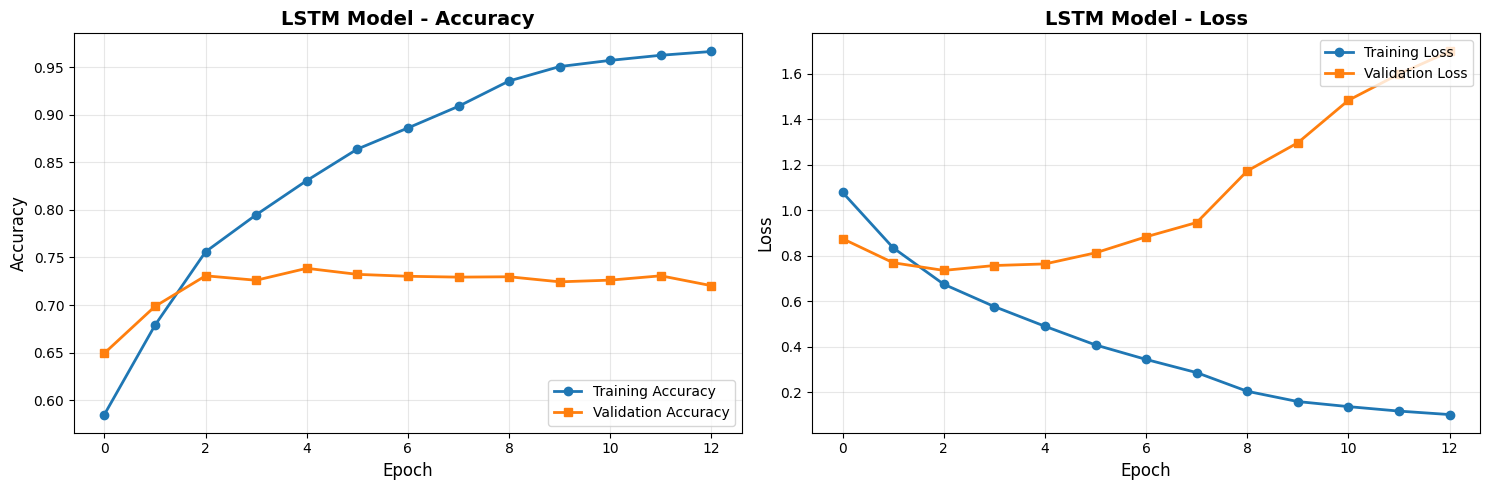

✅ Training history plot saved: results/02_lstm_training_history.png


In [12]:
# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history_lstm.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o')
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s')
axes[0].set_title('LSTM Model - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_lstm.history['loss'], label='Training Loss', linewidth=2, marker='o')
axes[1].plot(history_lstm.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
axes[1].set_title('LSTM Model - Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/02_lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training history plot saved: results/02_lstm_training_history.png")

## 🎯 Evaluasi Model pada Test Set

In [13]:
# Load best model
from tensorflow.keras.models import load_model
lstm_model = load_model('../models/lstm_model.h5')

print("✅ Best model loaded")

✅ Best model loaded


In [14]:
# Predict pada test set
print("🔮 Predicting on test set...")
y_pred_proba = lstm_model.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("✅ Prediction complete!")

🔮 Predicting on test set...
✅ Prediction complete!


## 📋 Classification Report

In [15]:
# Classification Report
print("="*80)
print("📋 LSTM MODEL - CLASSIFICATION REPORT")
print("="*80)
print()
class_report = classification_report(
    y_test, 
    y_pred, 
    target_names=label_encoder.classes_,
    digits=4
)
print(class_report)

# Save classification report
with open('../results/02_lstm_classification_report.txt', 'w') as f:
    f.write(class_report)

print("💾 Classification report saved: results/02_lstm_classification_report.txt")

📋 LSTM MODEL - CLASSIFICATION REPORT

                      precision    recall  f1-score   support

             Anxiety     0.7950    0.6597    0.7211       576
             Bipolar     0.7118    0.6930    0.7023       417
          Depression     0.6679    0.6986    0.6829      2309
              Normal     0.8698    0.9298    0.8988      2451
Personality disorder     0.6031    0.4907    0.5411       161
              Stress     0.4950    0.5129    0.5038       388
            Suicidal     0.6441    0.5836    0.6124      1597

            accuracy                         0.7306      7899
           macro avg     0.6838    0.6526    0.6660      7899
        weighted avg     0.7275    0.7306    0.7278      7899

💾 Classification report saved: results/02_lstm_classification_report.txt


In [16]:
# Calculate accuracy
lstm_accuracy = accuracy_score(y_test, y_pred)

print("="*80)
print(f"🎯 LSTM MODEL TEST ACCURACY: {lstm_accuracy:.4f} ({lstm_accuracy*100:.2f}%)")
print("="*80)

🎯 LSTM MODEL TEST ACCURACY: 0.7306 (73.06%)


## 🔲 Confusion Matrix

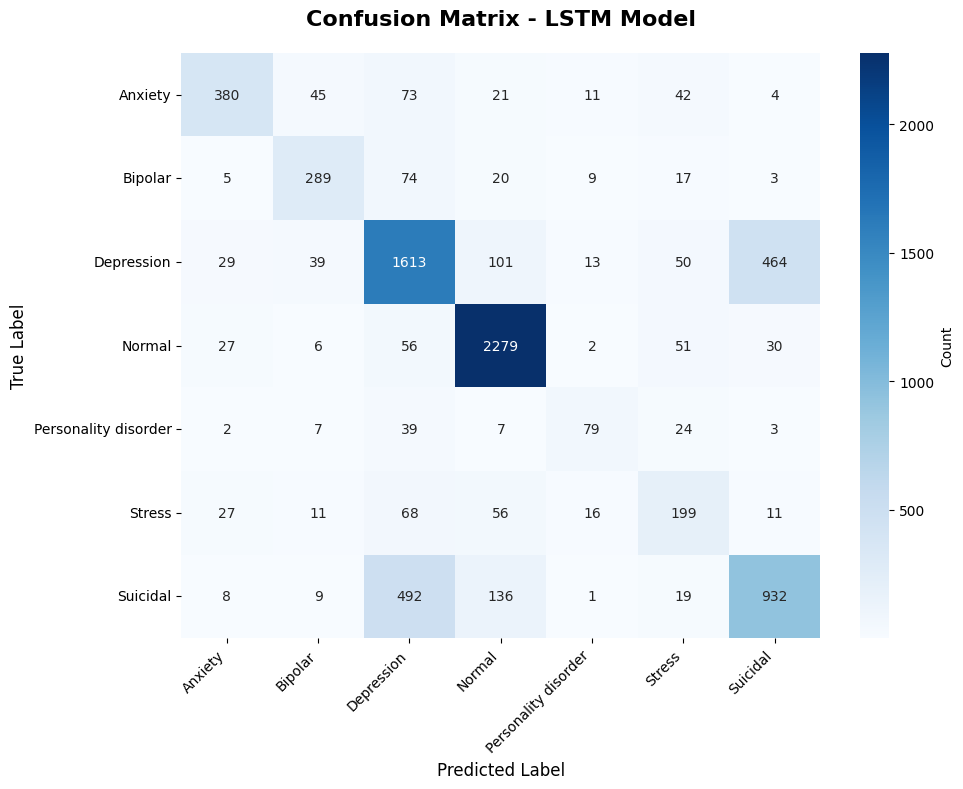

✅ Confusion matrix saved: results/02_lstm_confusion_matrix.png


In [17]:
# Confusion Matrix
cm_lstm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_lstm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - LSTM Model', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/02_lstm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved: results/02_lstm_confusion_matrix.png")

## 💾 Simpan Hasil Evaluasi

In [18]:
# Simpan hasil evaluasi dalam format yang mudah dibaca
lstm_results = {
    'model_name': 'LSTM (Non-Pretrained)',
    'accuracy': float(lstm_accuracy),
    'test_size': len(y_test),
    'num_classes': num_classes,
    'hyperparameters': {
        'max_words': MAX_WORDS,
        'max_len': MAX_LEN,
        'embedding_dim': EMBEDDING_DIM,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE
    },
    'training_history': {
        'epochs_trained': len(history_lstm.history['accuracy']),
        'final_train_accuracy': float(history_lstm.history['accuracy'][-1]),
        'final_val_accuracy': float(history_lstm.history['val_accuracy'][-1]),
        'final_train_loss': float(history_lstm.history['loss'][-1]),
        'final_val_loss': float(history_lstm.history['val_loss'][-1]),
        'best_val_accuracy': float(max(history_lstm.history['val_accuracy'])),
        'best_val_loss': float(min(history_lstm.history['val_loss']))
    }
}

# Save to JSON
with open('../results/02_lstm_results.json', 'w') as f:
    json.dump(lstm_results, f, indent=4)

print("✅ Results saved: results/02_lstm_results.json")

✅ Results saved: results/02_lstm_results.json


In [19]:
# Simpan history untuk plotting nanti
history_dict = {
    'accuracy': [float(x) for x in history_lstm.history['accuracy']],
    'val_accuracy': [float(x) for x in history_lstm.history['val_accuracy']],
    'loss': [float(x) for x in history_lstm.history['loss']],
    'val_loss': [float(x) for x in history_lstm.history['val_loss']]
}

with open('../results/02_lstm_history.json', 'w') as f:
    json.dump(history_dict, f, indent=4)

print("✅ Training history saved: results/02_lstm_history.json")

✅ Training history saved: results/02_lstm_history.json


## 📊 Summary

In [20]:
print("\n" + "="*80)
print("📊 LSTM MODEL TRAINING SUMMARY")
print("="*80)

print(f"\n🏗️ Model Architecture:")
print(f"   - Type: Bidirectional LSTM")
print(f"   - Embedding Dimension: {EMBEDDING_DIM}")
print(f"   - Vocabulary Size: {MAX_WORDS:,}")
print(f"   - Sequence Length: {MAX_LEN}")
print(f"   - Total Parameters: {lstm_model.count_params():,}")

print(f"\n🏋️ Training:")
print(f"   - Epochs Trained: {len(history_lstm.history['accuracy'])}")
print(f"   - Batch Size: {BATCH_SIZE}")
print(f"   - Final Training Accuracy: {history_lstm.history['accuracy'][-1]:.4f}")
print(f"   - Final Validation Accuracy: {history_lstm.history['val_accuracy'][-1]:.4f}")

print(f"\n🎯 Test Results:")
print(f"   - Test Accuracy: {lstm_accuracy:.4f} ({lstm_accuracy*100:.2f}%)")
print(f"   - Test Samples: {len(y_test):,}")

print(f"\n💾 Files Saved:")
print(f"   ✓ models/lstm_model.h5")
print(f"   ✓ models/lstm_tokenizer.pkl")
print(f"   ✓ results/02_lstm_training_history.png")
print(f"   ✓ results/02_lstm_confusion_matrix.png")
print(f"   ✓ results/02_lstm_classification_report.txt")
print(f"   ✓ results/02_lstm_results.json")
print(f"   ✓ results/02_lstm_history.json")

print(f"\n🎯 Next Step: 03_bert_model.ipynb")
print("="*80)


📊 LSTM MODEL TRAINING SUMMARY

🏗️ Model Architecture:
   - Type: Bidirectional LSTM
   - Embedding Dimension: 256
   - Vocabulary Size: 20,000
   - Sequence Length: 128
   - Total Parameters: 7,016,583

🏋️ Training:
   - Epochs Trained: 13
   - Batch Size: 32
   - Final Training Accuracy: 0.9663
   - Final Validation Accuracy: 0.7203

🎯 Test Results:
   - Test Accuracy: 0.7306 (73.06%)
   - Test Samples: 7,899

💾 Files Saved:
   ✓ models/lstm_model.h5
   ✓ models/lstm_tokenizer.pkl
   ✓ results/02_lstm_training_history.png
   ✓ results/02_lstm_confusion_matrix.png
   ✓ results/02_lstm_classification_report.txt
   ✓ results/02_lstm_results.json
   ✓ results/02_lstm_history.json

🎯 Next Step: 03_bert_model.ipynb
